#### import 套件

In [1]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import signal
from scipy.stats import pearsonr
from sklearn.cluster import KMeans
from scipy.signal import find_peaks
from sklearn.feature_selection import mutual_info_classif

#### load power trace

In [2]:
trace_num = 2000
order = '3'
opt = 'o3' # o0 or o3
scope = '' # _chipwhisperer or space
algo = 'PQClean' # orgPoly or PQClean or pqm4
platform = 'CW308_STM32F4' # CW308_STM32F3 or CW308_STM32F4 or CWLITEARM

trace_path = f'traces{scope}/{trace_num}/traces_unfixed_message_{trace_num}_{platform}_{opt}_{algo}_{order}'


t = np.load(f'{trace_path}/trace.npy')
l = np.load(f'{trace_path}/message.npy')

#### 確認trace和label的大小

In [3]:
print("Size of Trace: ", end="")
print(t.shape)
print(t)
print("\nSize of Message: ", end="")
print(l.shape)
print(l)

Size of Trace: (2000, 455000)
[[-2.98193139e-03 -1.71529728e-03 -1.28189476e-04 ...  7.41972897e-03
   6.53155903e-03  4.88035649e-03]
 [-2.53937248e-03 -8.88169943e-04  1.89232084e-04 ...  8.11561470e-03
   7.10230741e-03  5.13673544e-03]
 [-2.79269930e-03 -1.14454890e-03  0.00000000e+00 ...  3.54962764e-03
   2.72555244e-03  3.04297400e-03]
 ...
 [-2.91783665e-03 -1.58710780e-03  6.10426077e-05 ...  5.76852643e-03
   3.93114394e-03  2.91478452e-03]
 [-3.87010133e-03 -2.53937248e-03 -8.88169943e-04 ...  7.35563423e-03
   7.67305579e-03  6.78488585e-03]
 [-3.36344769e-03 -2.02966671e-03 -2.56378953e-04 ...  6.46746429e-03
   7.35563423e-03  6.97411793e-03]]

Size of Message: (2000, 32)
[[116. 224.  11. ...   5. 141.  26.]
 [252.   7. 243. ...  58.  26.  43.]
 [ 22.  73.   3. ... 166.  16. 124.]
 ...
 [101.  94. 126. ... 250.  70.  99.]
 [  4.  99. 150. ... 140. 211. 153.]
 [211. 254. 103. ...  72. 192.  66.]]


In [4]:
#### 印出單條trace

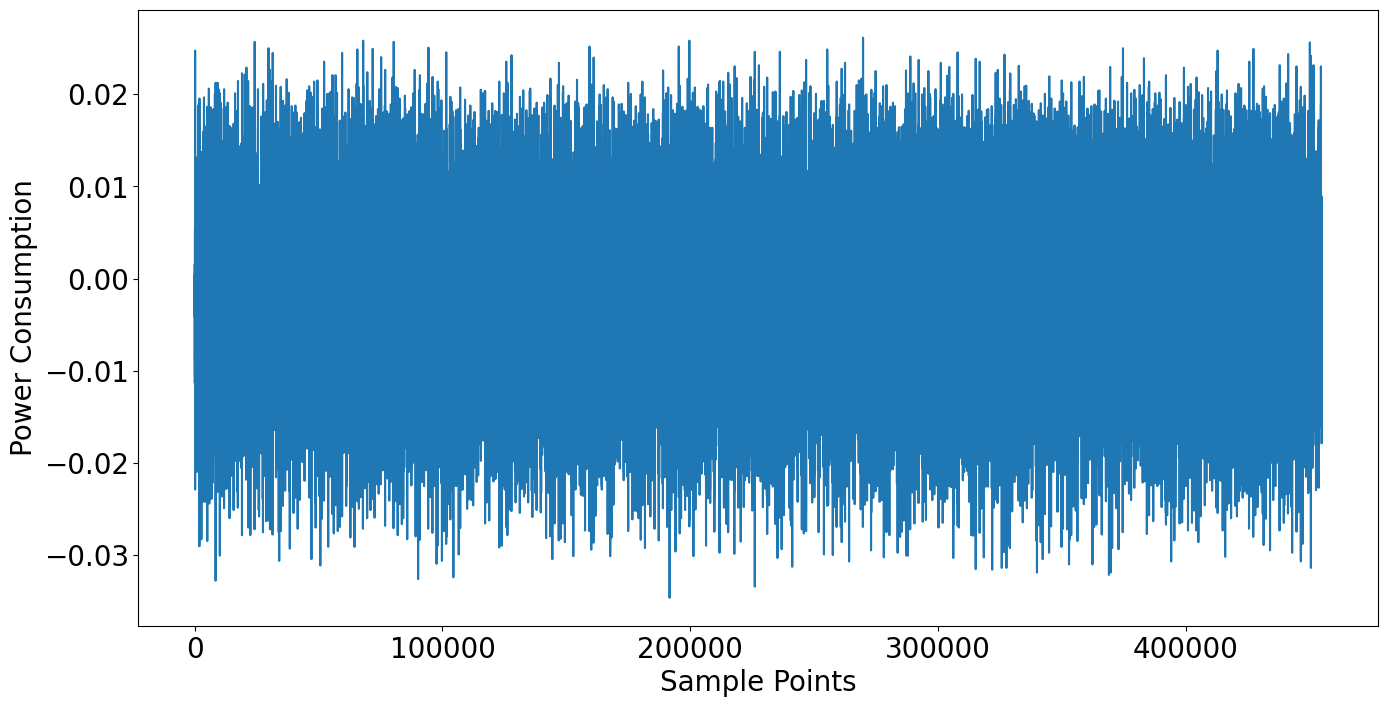

In [5]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(t[0])

#### 多條平均

In [6]:
mean_t = np.mean(t, axis=0)
print(mean_t)

[-0.00299086 -0.00151945 -0.00010835 ...  0.0065625   0.00624067
  0.00530993]


#### 印出平均Trace

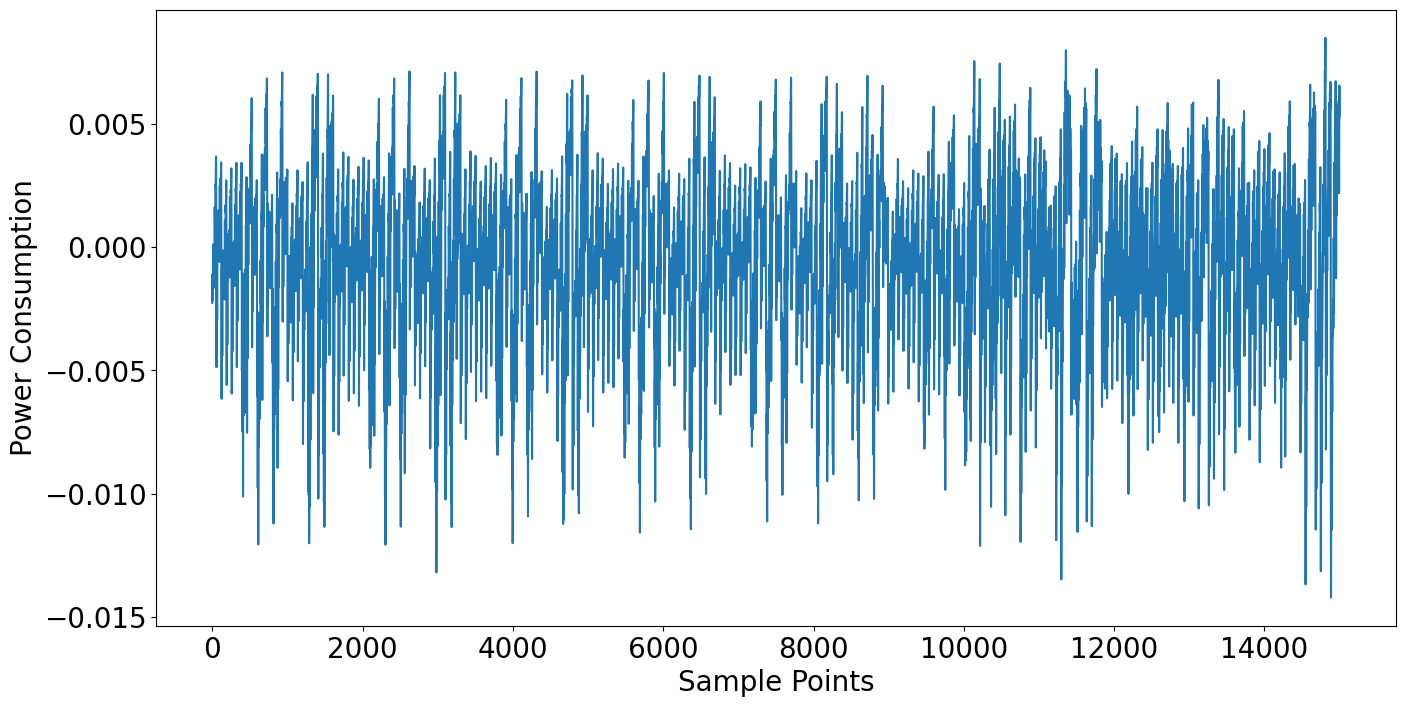

In [7]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(mean_t[440000:])

#### 確認開始位置、結束位置、分割大小、儲存分割後結果

In [8]:
def optimize_start_point_and_segment(trace_data, num_segments=32, max_length=None, max_start_search=1000):
    """
    自動尋找最佳起始點，檢測有效訊號邊界，並將訊號切割為指定數量的片段
    
    參數:
    trace_data: 原始訊號數據
    num_segments: 要切割的段數（默認為32個字節）
    max_length: 訊號的最大可能長度（如果已知）
    max_start_search: 搜索起始點的最大範圍
    
    返回:
    segments: 切割好的片段列表
    start_index: 檢測到的最佳起始點
    end_index: 檢測到的有效訊號結束位置
    segment_length: 每個片段的長度
    """
    if max_length is not None and max_length < len(trace_data):
        # 如果提供了最大長度限制，先截取
        trace_data = trace_data[:max_length]
    
    # 步驟1: 使用自相關分析找出週期性模式
    autocorr = signal.correlate(trace_data, trace_data, mode='full')
    autocorr = autocorr[len(autocorr)//2:]
    
    # 尋找自相關中的顯著峰值
    approx_segment_len = len(trace_data) // num_segments
    min_distance = approx_segment_len * 0.7  # 最小峰值間距
    
    peaks, _ = signal.find_peaks(autocorr, 
                               height=0.4*max(autocorr), 
                               distance=min_distance)
    
    # 從峰值中估計片段長度
    if len(peaks) >= 3:  # 至少需要3個峰值來獲得可靠估計
        peak_distances = np.diff(peaks)
        estimated_period = int(np.median(peak_distances))
    else:
        # 如果找不到足夠的峰值，使用近似值
        estimated_period = approx_segment_len
    
    # 步驟2: 搜索最佳起始點
    best_start = 0
    best_correlation = -np.inf
    max_start = min(max_start_search, len(trace_data) - estimated_period * num_segments)
    
    # 嘗試不同的起始點，找到使得所有片段相似度最高的起始點
    for start in range(0, max_start, max(1, max_start // 100)):  # 使用步長來加速搜索
        # 從當前起始點切割片段
        segments = []
        for i in range(num_segments):
            segment_start = start + i * estimated_period
            segment_end = start + (i + 1) * estimated_period
            
            if segment_end <= len(trace_data):
                segment = trace_data[segment_start:segment_end]
                segments.append(segment)
        
        # 如果無法切割出足夠的片段，跳過此起始點
        if len(segments) < num_segments:
            continue
        
        # 計算所有片段之間的相關係數平均值
        correlations = []
        for i in range(len(segments)-1):
            # 只計算相鄰片段的相關係數，加速計算
            corr, _ = pearsonr(segments[i], segments[i+1])
            correlations.append(corr)
        
        avg_correlation = np.mean(correlations)
        
        # 如果找到更好的起始點，更新最佳值
        if avg_correlation > best_correlation:
            best_correlation = avg_correlation
            best_start = start
    
    print(f"找到的最佳起始點: {best_start}")
    print(f"最佳起始點的平均相關係數: {best_correlation:.4f}")
    
    # 步驟3: 使用最佳起始點和估計的段長重新切割
    segments = []
    for i in range(num_segments):
        segment_start = best_start + i * estimated_period
        segment_end = best_start + (i + 1) * estimated_period
        
        if segment_end <= len(trace_data):
            segment = trace_data[segment_start:segment_end]
            segments.append(segment)
    
    # 步驟4: 使用變異度分析檢測訊號的結束位置（如果需要）
    if len(segments) < num_segments:
        print(f"警告: 只能切割出 {len(segments)} 個片段，少於預期的 {num_segments} 個")
        end_index = len(trace_data)
    else:
        end_index = best_start + num_segments * estimated_period
        end_index = min(end_index, len(trace_data))
    
    # 步驟5: 計算片段間相似度矩陣
    similarity_matrix = np.zeros((len(segments), len(segments)))
    for i in range(len(segments)):
        for j in range(len(segments)):
            if i != j:
                corr, _ = pearsonr(segments[i], segments[j])
                similarity_matrix[i, j] = corr
    
    avg_similarity = np.mean(similarity_matrix)
    print(f"平均片段相似度: {avg_similarity:.4f}")
    print(f"檢測到的有效訊號結束位置: {end_index}")
    print(f"每個片段的長度: {estimated_period}")
    print(f"實際切割的片段數: {len(segments)}")
    
    return segments, best_start, end_index, estimated_period

#### 對分割後的trace進行位移，找大最大的相關性

In [9]:
def find_optimal_alignment(segments, threshold=0.7):
    """
    尋找片段間的最佳對齊，處理可能的時間偏移
    
    參數:
    segments: 切割出的片段列表
    threshold: 相關係數閾值，用於判斷對齊質量
    
    返回:
    aligned_segments: 對齊後的片段列表
    shifts: 每個片段的偏移點數列表
    """
    # 選擇第一個段作為參考
    reference = segments[0]
    aligned_segments = [reference]
    
    # 創建一個列表來存儲每個片段的偏移點數
    shifts = [0]  # 第一個片段(參考片段)偏移量為0
    
    # 對其他段進行對齊
    for i in range(1, len(segments)):
        current = segments[i]
        best_shift = 0
        best_corr = -np.inf
        
        # 在一個小範圍內嘗試不同的偏移
        max_shift = min(len(reference), len(current)) // 10
        for shift in range(-max_shift, max_shift+1):
            if shift < 0:
                # 負偏移: 當前段向左移動
                ref_slice = reference[0:min(len(reference), len(current)+shift)]
                cur_slice = current[-shift:min(len(current), len(reference)-shift)]
            else:
                # 正偏移: 當前段向右移動
                ref_slice = reference[shift:min(len(reference), len(current)+shift)]
                cur_slice = current[0:min(len(current), len(reference)-shift)]
            
            # 確保兩個切片長度相同
            min_len = min(len(ref_slice), len(cur_slice))
            if min_len > 10:  # 確保有足夠的數據點進行相關性計算
                corr, _ = pearsonr(ref_slice[:min_len], cur_slice[:min_len])  # 修正了此處的錯誤
                if corr > best_corr:
                    best_corr = corr
                    best_shift = shift
        
        # 應用最佳偏移
        if best_shift < 0:
            aligned_segment = np.zeros_like(reference)
            aligned_segment[0:min(len(aligned_segment), len(current)+best_shift)] = current[-best_shift:min(len(current), len(reference)-best_shift)]
        else:
            aligned_segment = np.zeros_like(reference)
            copy_len = min(len(current), len(reference)-best_shift)
            aligned_segment[best_shift:best_shift+copy_len] = current[0:copy_len]
        
        aligned_segments.append(aligned_segment)
        shifts.append(best_shift)  # 記錄當前片段的偏移量
        
        print(f"片段 {i+1} 最佳偏移: {best_shift}, 相關係數: {best_corr:.4f}")
    
    return aligned_segments, shifts

In [10]:
segments, start_index, end_index, segment_length = optimize_start_point_and_segment(mean_t, max_start_search=1)

找到的最佳起始點: 0
最佳起始點的平均相關係數: 0.9888
平均片段相似度: 0.7291
檢測到的有效訊號結束位置: 448512
每個片段的長度: 14016
實際切割的片段數: 32


In [11]:
aligned_segments, shifts = find_optimal_alignment(segments)

片段 2 最佳偏移: 0, 相關係數: 0.9680
片段 3 最佳偏移: -1, 相關係數: 0.9711
片段 4 最佳偏移: -1, 相關係數: 0.9761
片段 5 最佳偏移: -1, 相關係數: 0.9718
片段 6 最佳偏移: -1, 相關係數: 0.9697
片段 7 最佳偏移: -2, 相關係數: 0.9699
片段 8 最佳偏移: -2, 相關係數: 0.9766
片段 9 最佳偏移: -2, 相關係數: 0.9707
片段 10 最佳偏移: -3, 相關係數: 0.9711
片段 11 最佳偏移: -3, 相關係數: 0.9808
片段 12 最佳偏移: -3, 相關係數: 0.9694
片段 13 最佳偏移: -4, 相關係數: 0.9723
片段 14 最佳偏移: -4, 相關係數: 0.9788
片段 15 最佳偏移: -4, 相關係數: 0.9715
片段 16 最佳偏移: -5, 相關係數: 0.9705
片段 17 最佳偏移: -5, 相關係數: 0.9738
片段 18 最佳偏移: -5, 相關係數: 0.9766
片段 19 最佳偏移: -5, 相關係數: 0.9710
片段 20 最佳偏移: -6, 相關係數: 0.9710
片段 21 最佳偏移: -6, 相關係數: 0.9809
片段 22 最佳偏移: -6, 相關係數: 0.9706
片段 23 最佳偏移: -7, 相關係數: 0.9709
片段 24 最佳偏移: -7, 相關係數: 0.9790
片段 25 最佳偏移: -7, 相關係數: 0.9718
片段 26 最佳偏移: -8, 相關係數: 0.9722
片段 27 最佳偏移: -8, 相關係數: 0.9754
片段 28 最佳偏移: -8, 相關係數: 0.9751
片段 29 最佳偏移: -8, 相關係數: 0.9710
片段 30 最佳偏移: -9, 相關係數: 0.9728
片段 31 最佳偏移: -9, 相關係數: 0.9784
片段 32 最佳偏移: -9, 相關係數: 0.9702


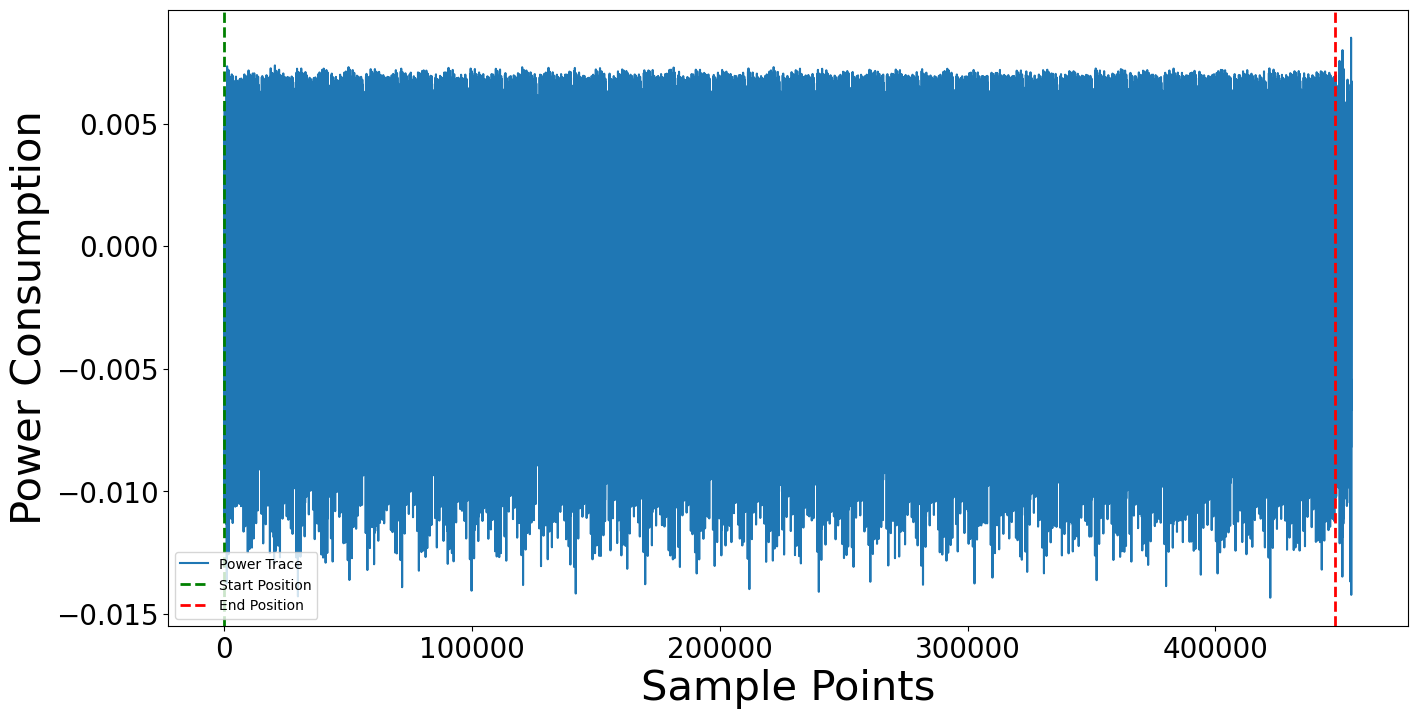

In [12]:
"""Draw more detailed analysis results"""
plt.figure(figsize=(16, 8))
plt.plot(mean_t[5:])
plt.axvline(x=start_index, color='g', linestyle='--', linewidth=2)
plt.axvline(x=end_index, color='r', linestyle='--', linewidth=2)
plt.legend(['Power Trace', 'Start Position', 'End Position'])
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)
plt.savefig(f'figure/trace_preprocess_split/{platform}_{opt}_power_trace_start_n_end_position.png', dpi=200, bbox_inches='tight')

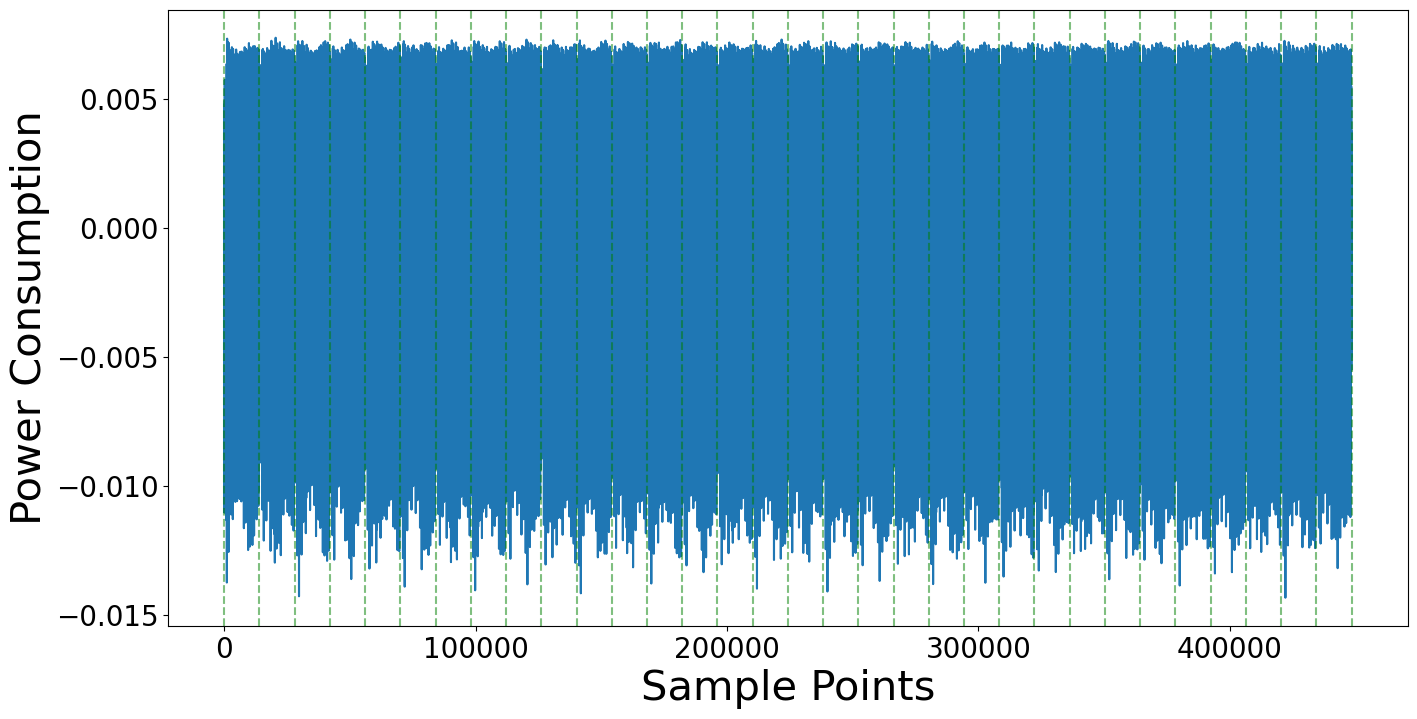

In [13]:
plt.figure(figsize=(16, 8))
plt.plot(mean_t[start_index:end_index])
for i in range(0, end_index - start_index+1, segment_length):
    plt.axvline(x=i, color='g', linestyle='--', alpha=0.5)
# plt.title('Segmentation of the Power Trace', fontsize=20)
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)

plt.savefig(f'figure/trace_preprocess_split/{platform}_{opt}_split_power_trace.png', dpi=200, bbox_inches='tight')

#### 分割後疊加

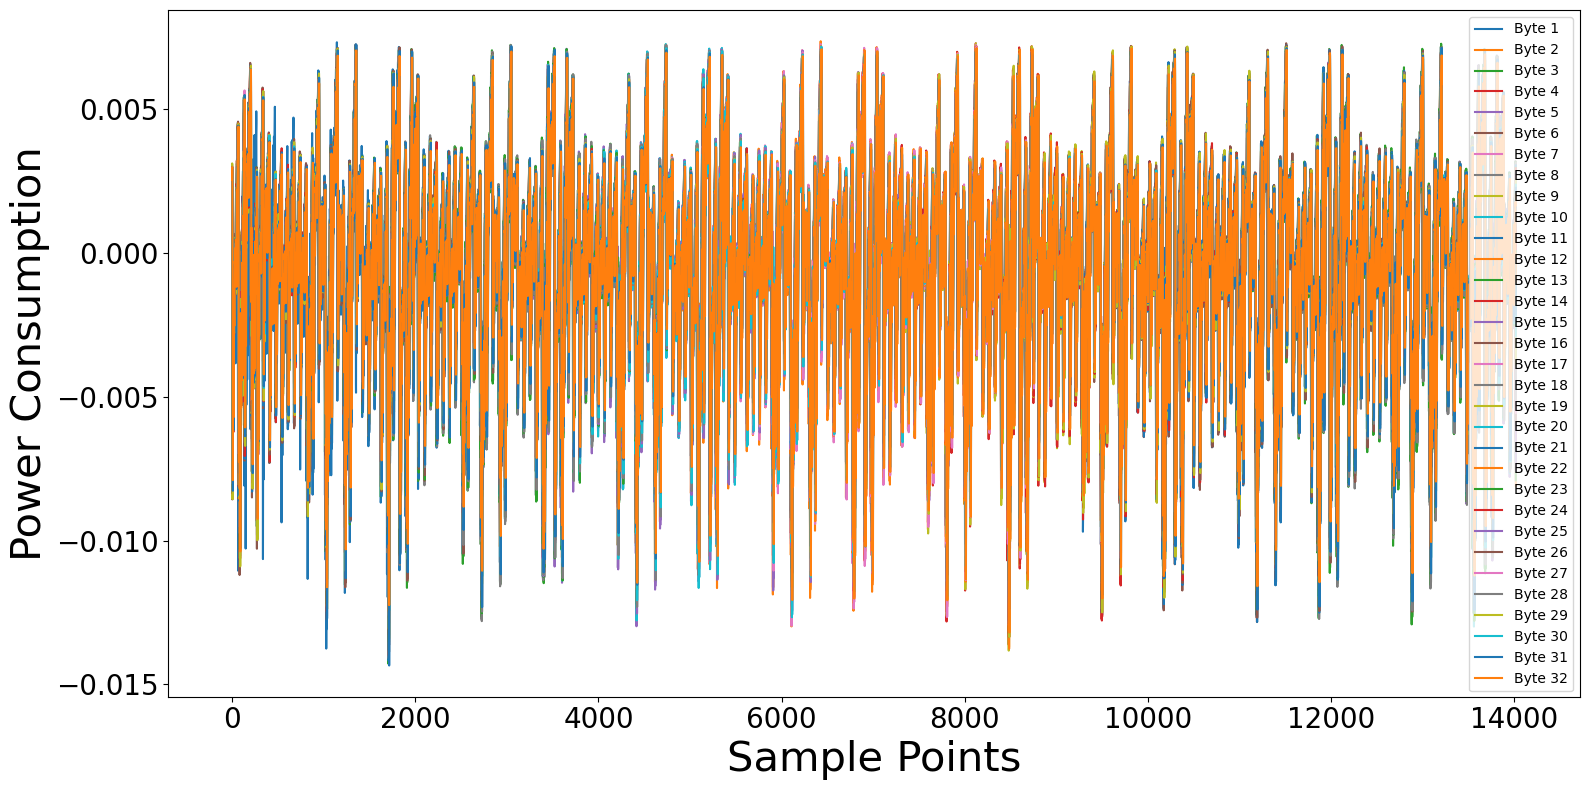

In [14]:
# Overlay display of original cut segments
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x-axis tick font size
plt.rc('ytick', labelsize=20)   # y-axis tick font size
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)
for i, segment in enumerate(segments):
    if i < 32: #5 or i > len(segments) - 3:
        plt.plot(segment, label=f'Byte {i+1}')
    else:
        plt.plot(segment, alpha=0.3)
# plt.title(f'Overlay Display of {len(segments)} Original Byte Segments')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'figure/trace_preprocess_split/{platform}_{opt}_overlay_32_segment_org.png', dpi=200, bbox_inches='tight')
plt.show()

#### 疊加後彼此的相關係數

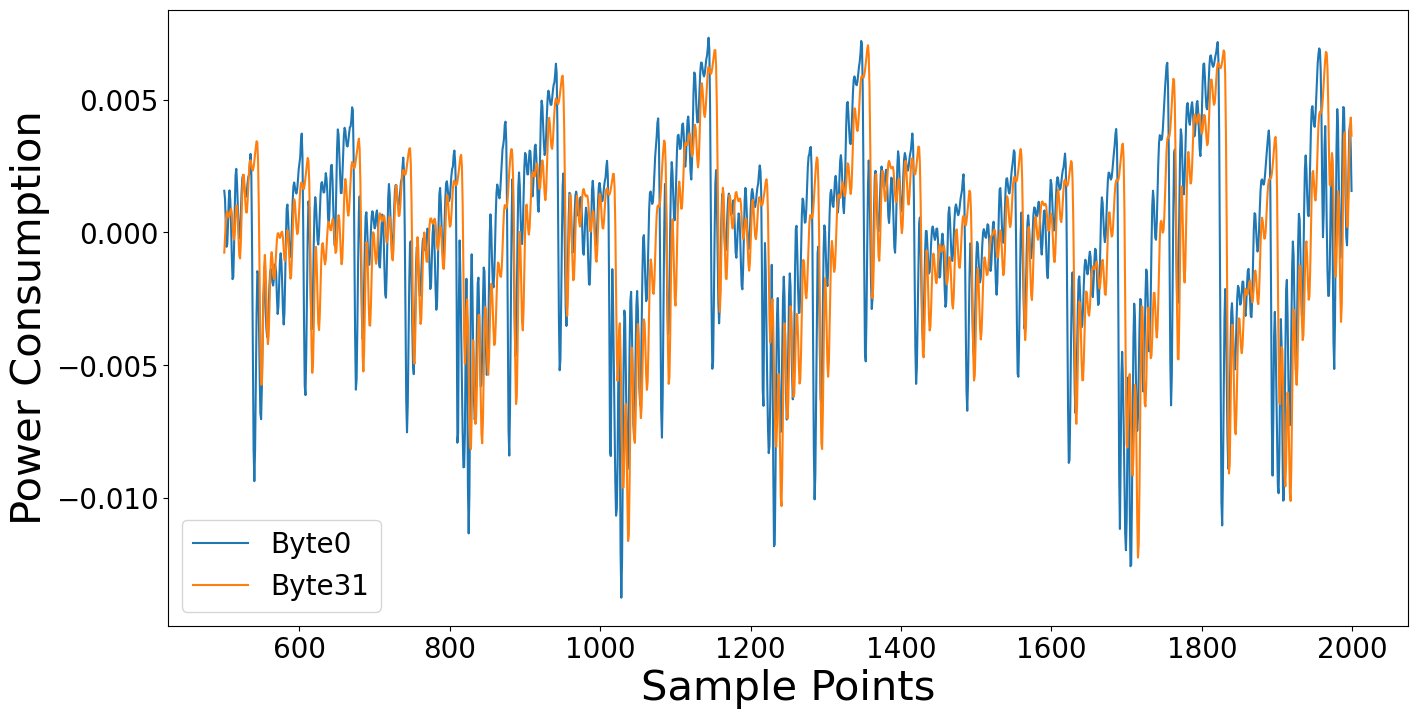

In [15]:
x = np.arange(500, 2000)
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)
plt.plot(x, segments[0][500:2000], label='Byte0')
plt.plot(x, segments[31][500:2000], label='Byte31')
plt.legend(fontsize=20, loc='best')
plt.savefig(f'figure/trace_preprocess_split/{platform}_{opt}_org_zoom_in.png', dpi=200, bbox_inches='tight')

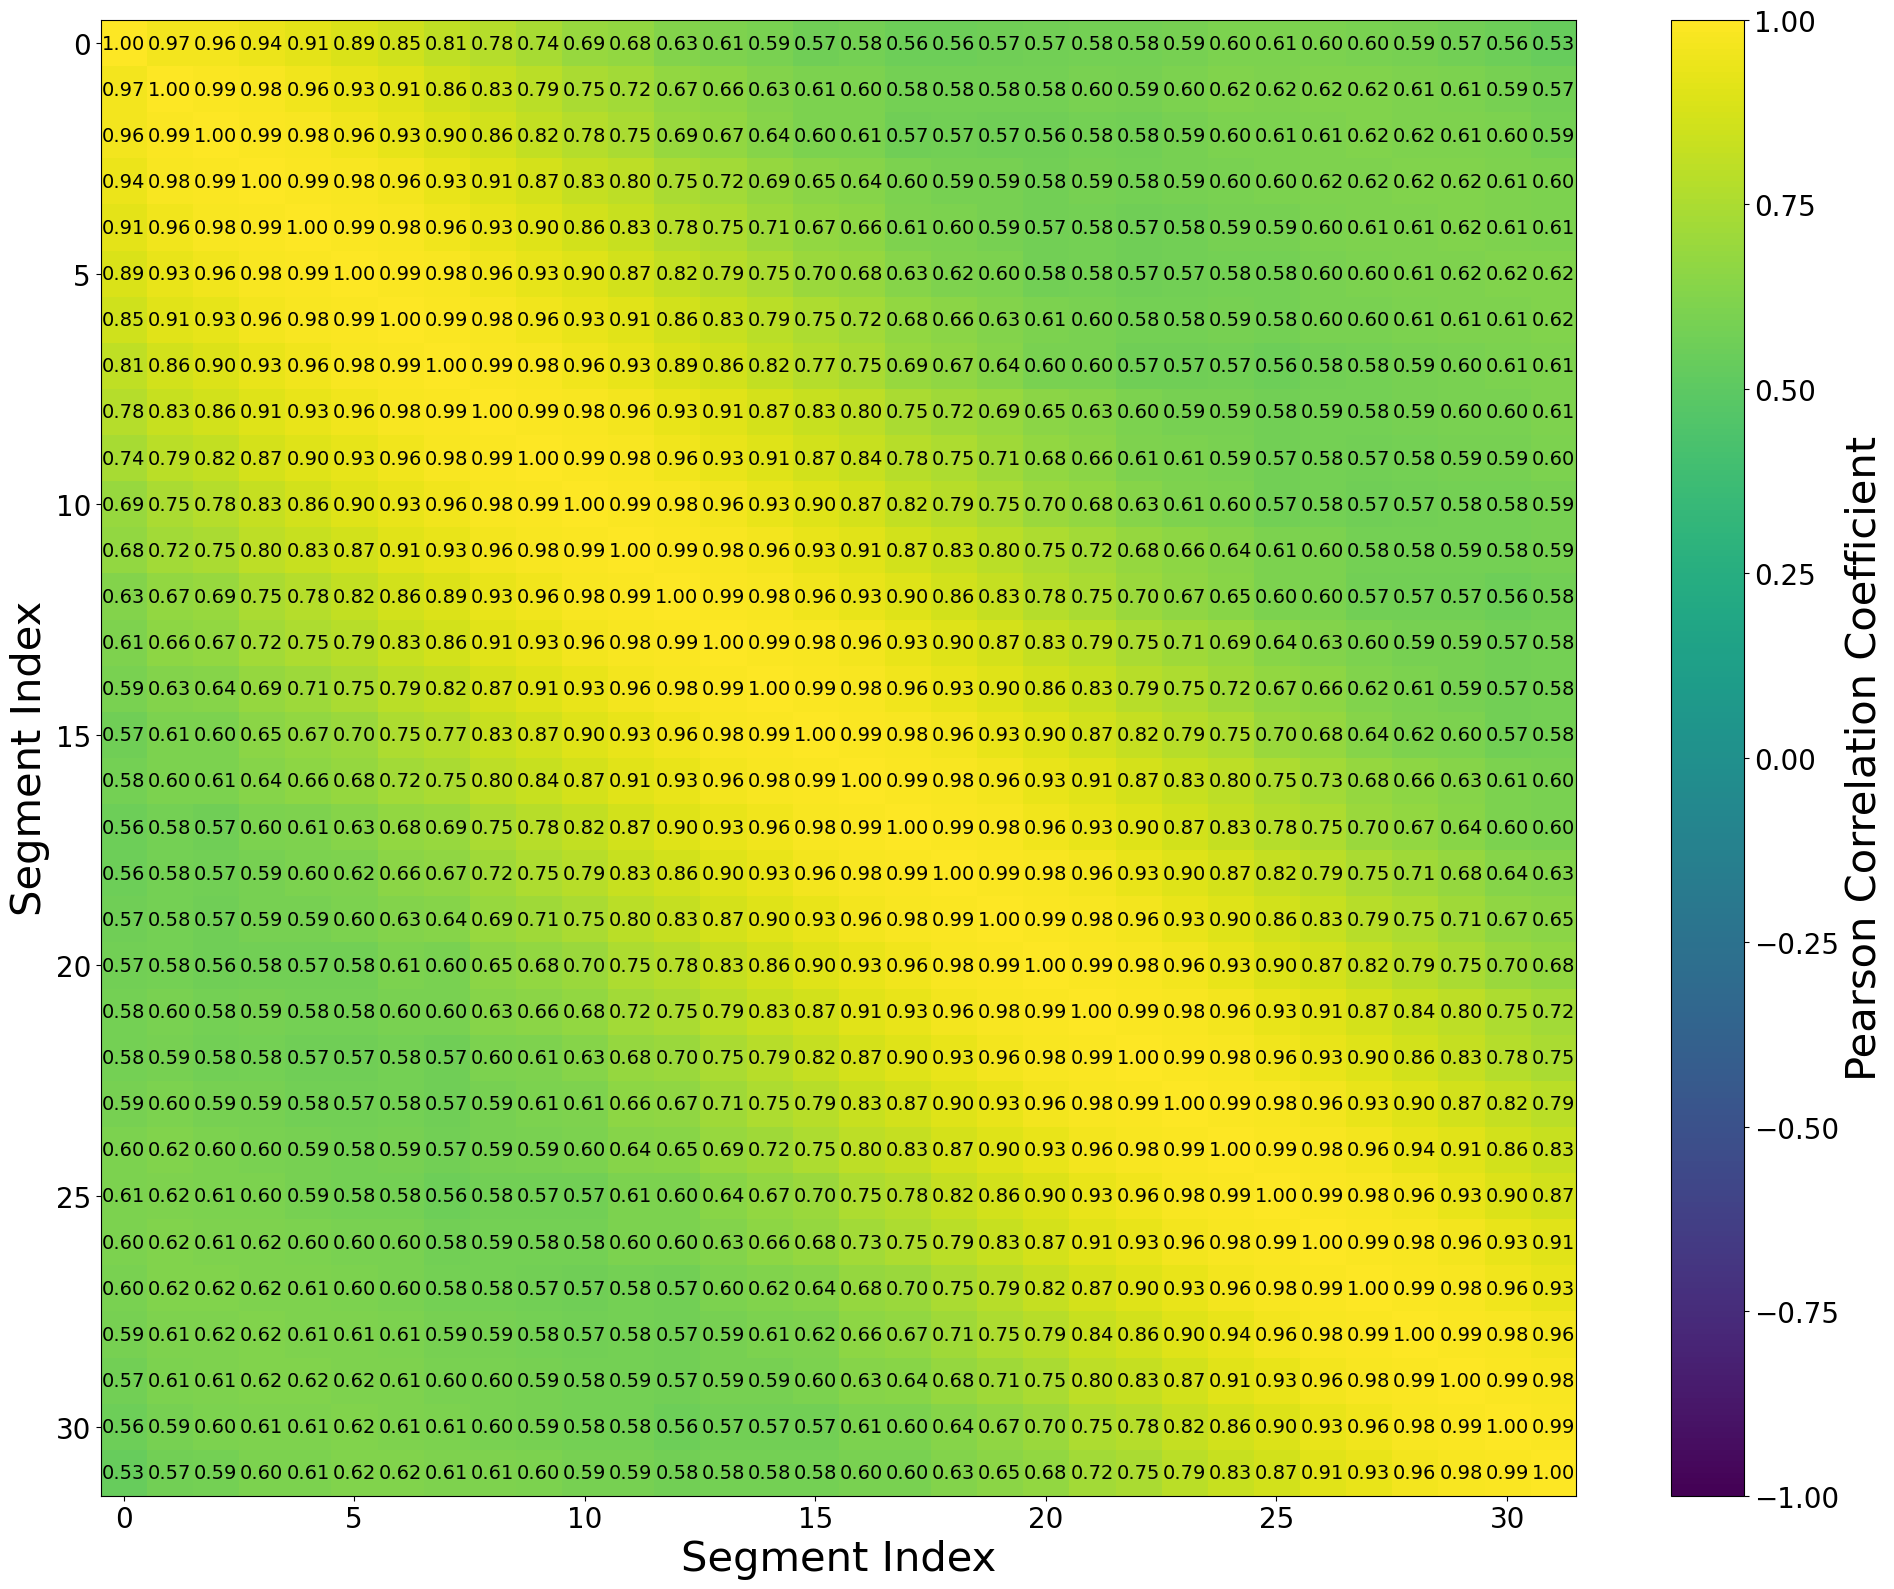

In [16]:
# Plot correlation heatmap of original segments with numerical values (including diagonal)
plt.figure(figsize=(20, 16))  # Increased figure size
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
if segments:
    corr_matrix = np.zeros((len(segments), len(segments)))
    
    for i in range(len(segments)):
        for j in range(len(segments)):
            if len(segments[i]) == len(segments[j]):
                corr, _ = pearsonr(segments[i], segments[j])
                corr_matrix[i, j] = corr
    
    # Display the heatmap with colors
    im = plt.imshow(corr_matrix, cmap='viridis', vmin=-1, vmax=1)
    
    # 建立 colorbar，並取得回傳的物件
    cbar = plt.colorbar(im, label='Pearson Correlation Coefficient')
    cbar.ax.tick_params(labelsize=20)
    cbar.set_label('Pearson Correlation Coefficient', fontsize=30)
    
    # Add numerical values
    num_segments = len(segments)
    
    
    for i in range(num_segments):
        for j in range(num_segments):
            if not np.isnan(corr_matrix[i, j]):  # Check if correlation was calculated
                # text_color = "white" if abs(corr_matrix[i, j]) < 0.5 else "black"
                text_color = "black"
                plt.text(j, i, f'{corr_matrix[i, j]:.2f}',
                       ha="center", va="center", color=text_color, fontsize=14)
            
    # plt.title('Correlation Heatmap Between Original Segments', fontsize=20)
    plt.xlabel('Segment Index', fontsize=30)
    plt.ylabel('Segment Index', fontsize=30)
    plt.tight_layout()
    plt.savefig(f'figure/trace_preprocess_split/{platform}_{opt}_heatmap_org.png', dpi=200, bbox_inches='tight')
    plt.show()

#### 分割後位移疊加

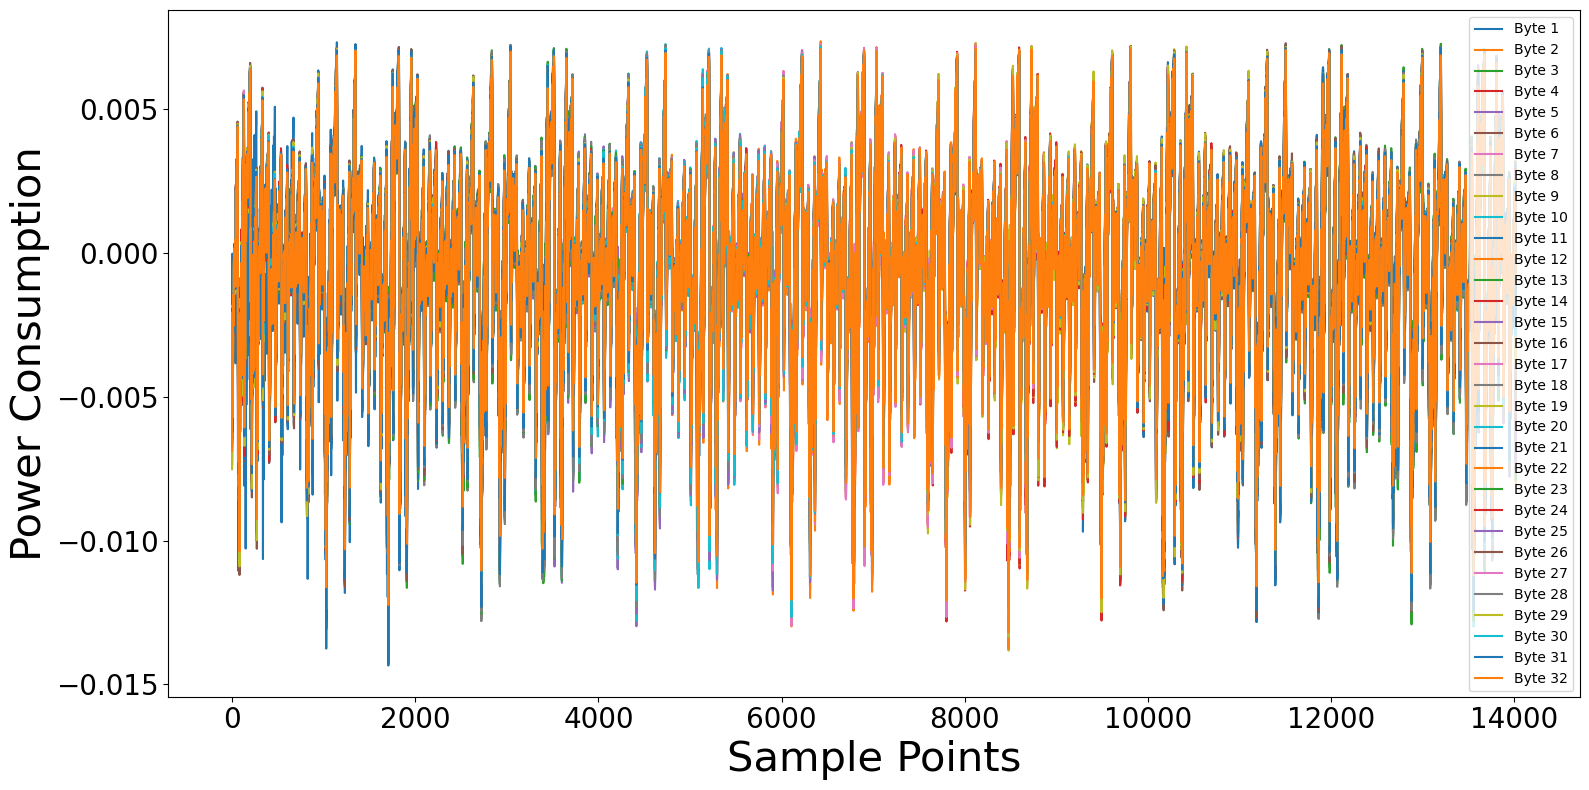

In [17]:
# Overlay display of aligned segments
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x-axis tick font size
plt.rc('ytick', labelsize=20)   # y-axis tick font size
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)
for i, segment in enumerate(aligned_segments):
    if i < 32: #5 or i > len(aligned_segments) - 3:
        plt.plot(segment, label=f'Byte {i+1}')
    else:
        plt.plot(segment, alpha=0.3)
# plt.title(f'Overlay Display of {len(aligned_segments)} Aligned Byte Segments')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'figure/trace_preprocess_split/{platform}_{opt}_overlay_32_segment_aligned.png', dpi=200, bbox_inches='tight')
plt.show()

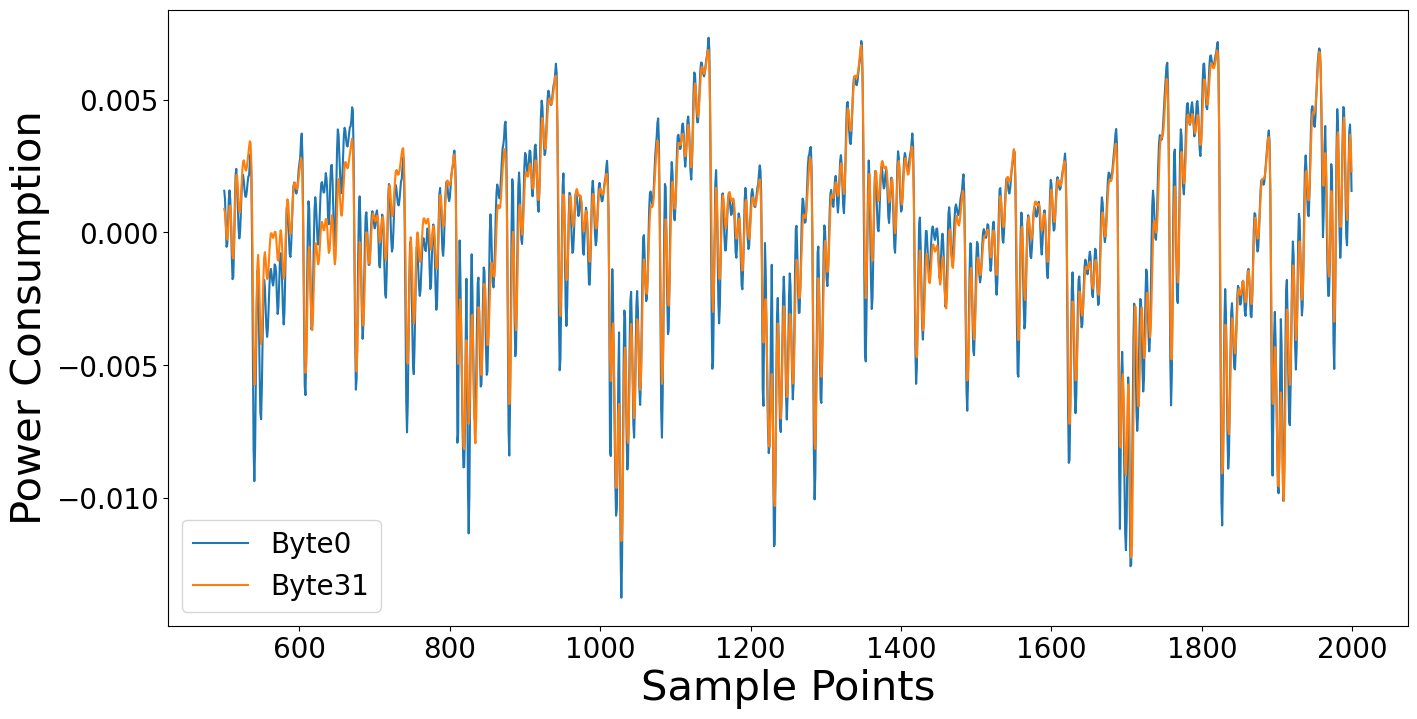

In [18]:
x = np.arange(500, 2000)
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)
plt.plot(x, aligned_segments[0][500:2000], label='Byte0')
plt.plot(x, aligned_segments[31][500:2000], label='Byte31')
plt.legend(fontsize=20, loc='best')
plt.savefig(f'figure/trace_preprocess_split/{platform}_{opt}_aligned_zoom_in.png', dpi=200, bbox_inches='tight')

#### 疊加後彼此的相關係數

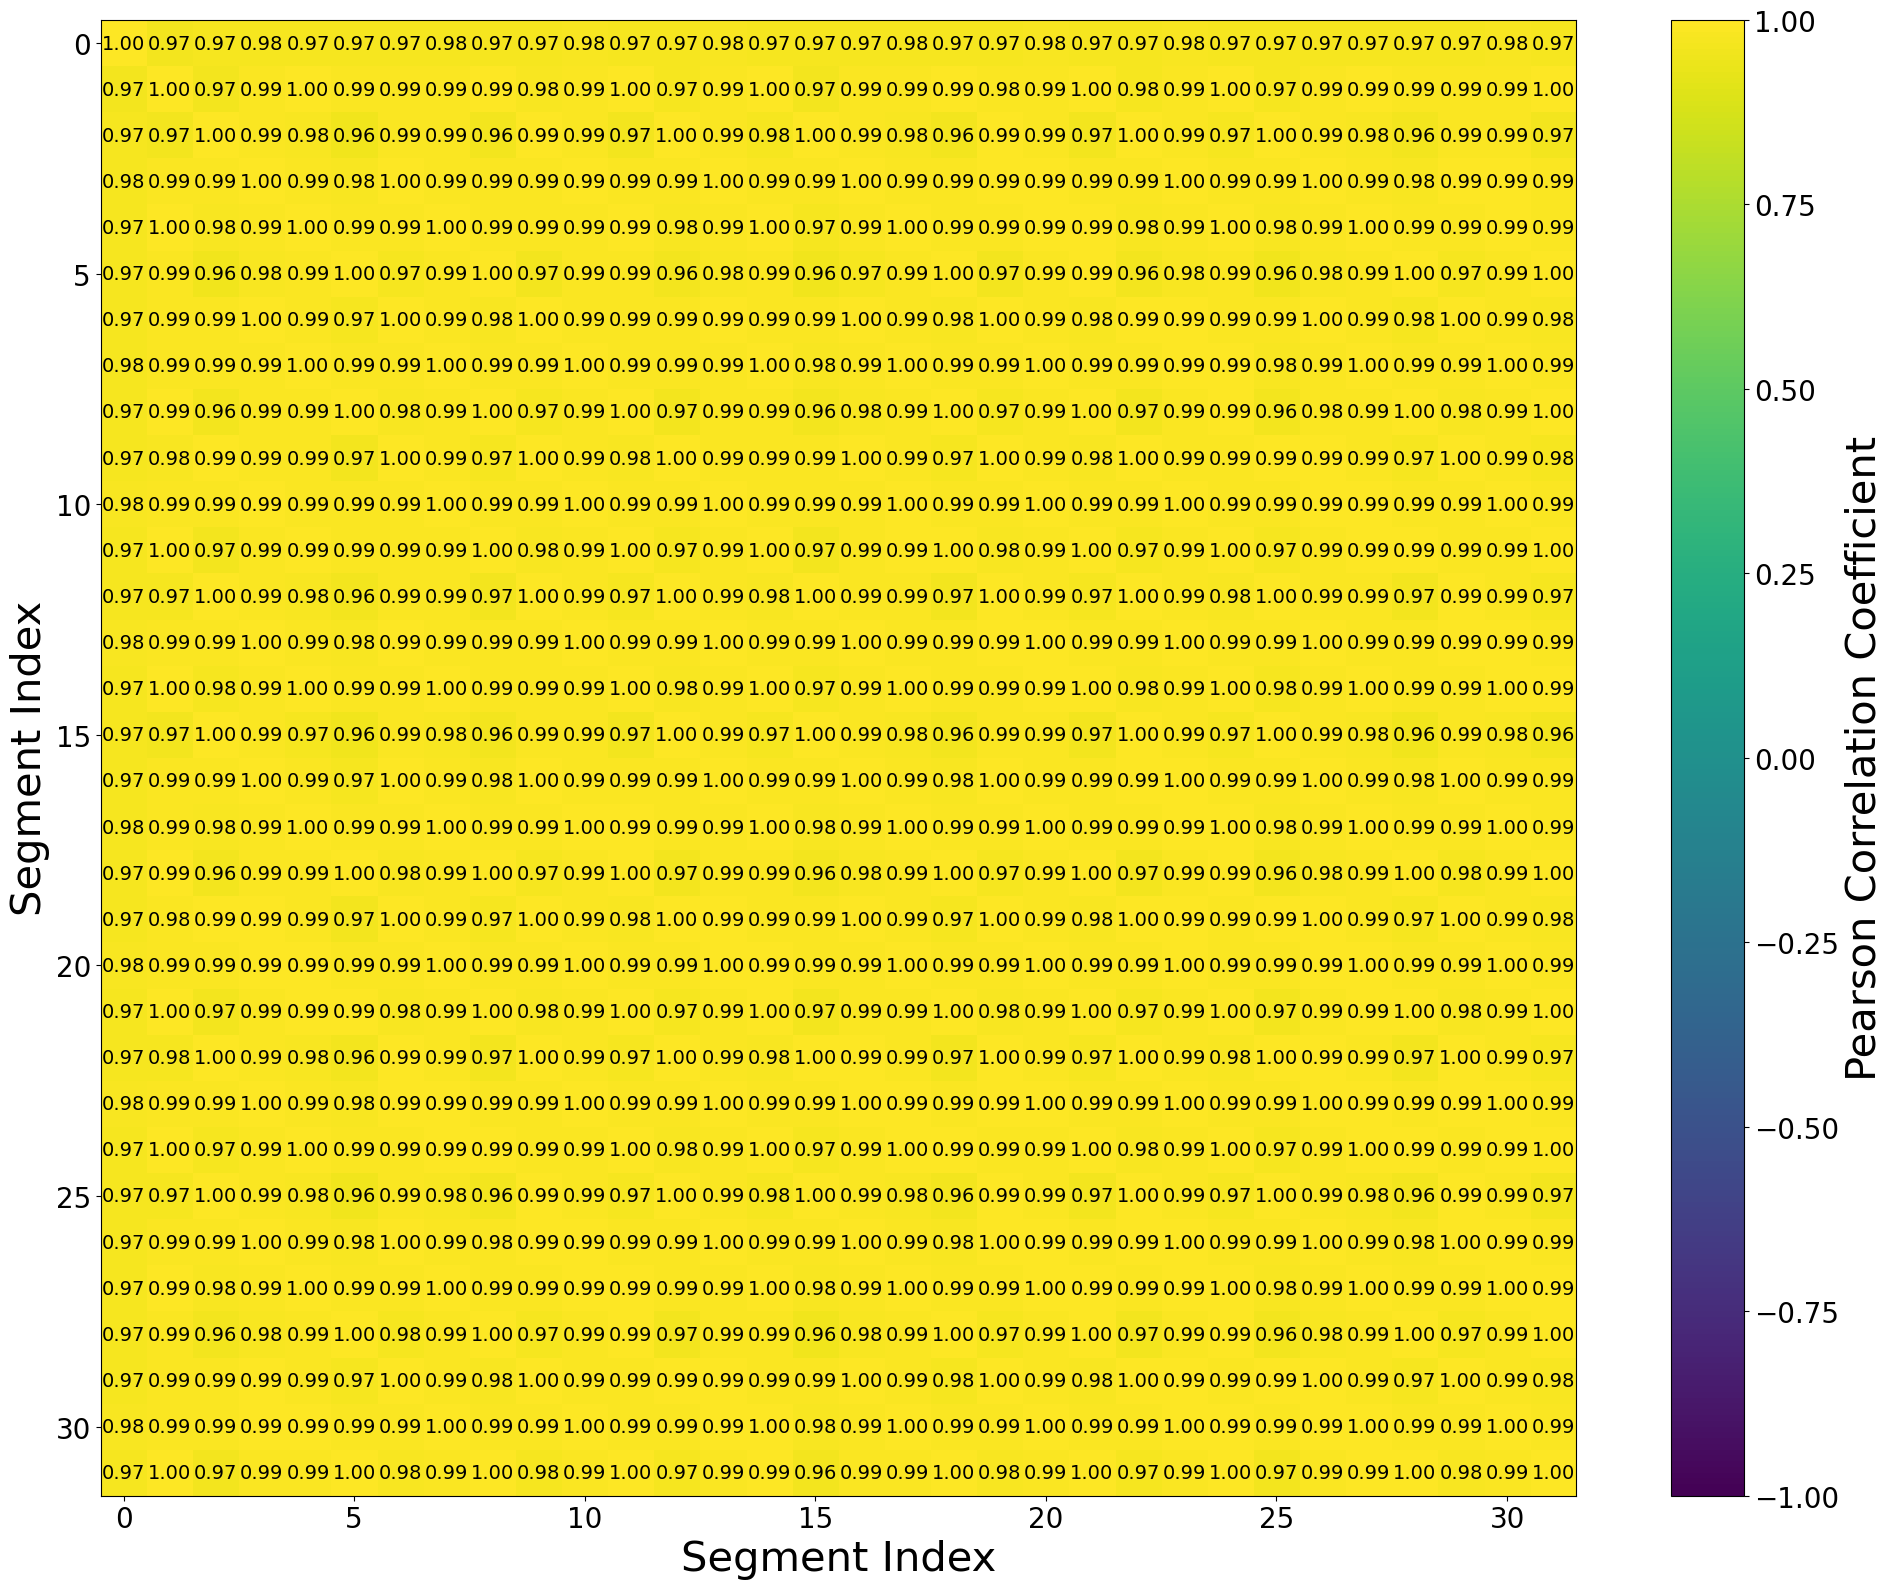

In [19]:
# Plot correlation heatmap of aligned segments with numerical values (including diagonal)
plt.figure(figsize=(20, 16))  # Increased figure size
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
if aligned_segments:
    aligned_corr_matrix = np.zeros((len(aligned_segments), len(aligned_segments)))
    
    for i in range(len(aligned_segments)):
        for j in range(len(aligned_segments)):
            corr, _ = pearsonr(aligned_segments[i], aligned_segments[j])
            aligned_corr_matrix[i, j] = corr
    
    # Display the heatmap with colors
    im = plt.imshow(aligned_corr_matrix, cmap='viridis', vmin=-1, vmax=1)

    # 建立 colorbar，並取得回傳的物件
    cbar = plt.colorbar(im, label='Pearson Correlation Coefficient')
    cbar.ax.tick_params(labelsize=20)
    cbar.set_label('Pearson Correlation Coefficient', fontsize=30)
    
    # Add numerical values
    num_segments = len(aligned_segments)
    
    for i in range(num_segments):
        for j in range(num_segments):
            if not np.isnan(aligned_corr_matrix[i, j]):  # Check if correlation was calculated
                # text_color = "white" if abs(corr_matrix[i, j]) < 0.5 else "black"
                text_color = "black"
                plt.text(j, i, f'{aligned_corr_matrix[i, j]:.2f}',
                       ha="center", va="center", color=text_color, fontsize=14)
            
    # plt.title('Correlation Heatmap Between Aligned Segments', fontsize=20)
    plt.xlabel('Segment Index', fontsize=30)
    plt.ylabel('Segment Index', fontsize=30)
    plt.tight_layout()
    plt.savefig(f'figure/trace_preprocess_split/{platform}_{opt}_heatmap_aligned.png', dpi=200, bbox_inches='tight')
    plt.show()

#### 真正對每一條功率軌跡進行分割

In [20]:
def process_new_signals_and_labels(new_signals, labels, best_start, segment_length, shifts, num_segments=32):
    """
    根據已知的最佳起始點、分割大小和偏移位置處理新訊號和對應的標籤
    
    參數:
    new_signals: 新訊號的列表或數組，每行是一條訊號
    labels: 標籤數組，形狀為 (2000, 32)
    best_start: 之前找到的最佳起始點
    segment_length: 每個片段的長度
    shifts: 每個片段的偏移量列表
    num_segments: 要切割的段數
    
    返回:
    processed_signals: 處理後的訊號二維數組，形狀為 (trace_num*32, segment_length)
    processed_labels: 處理後的標籤一維數組，長度為 trace_num*32
    """
    # 初始化存儲所有對齊段的列表
    all_aligned_segments = []
    all_aligned_labels = []
    
    # 迭代處理每條新訊號和對應的標籤
    for i, signal_data in enumerate(new_signals):
        # 確保訊號足夠長
        if len(signal_data) < best_start + num_segments * segment_length:
            print(f"警告：訊號 {i+1} 長度不足，無法使用相同的切割參數")
            continue
        
        # 切割片段
        segments = []
        for j in range(num_segments):
            segment_start = best_start + j * segment_length
            segment_end = segment_start + segment_length
            
            if segment_end <= len(signal_data):
                segment = signal_data[segment_start:segment_end]
                segments.append(segment)
            else:
                # 如果到達訊號末尾，用零填充
                segment = np.zeros(segment_length)
                valid_length = len(signal_data) - segment_start
                if valid_length > 0:
                    segment[:valid_length] = signal_data[segment_start:len(signal_data)]
                segments.append(segment)
        
        # 應用偏移
        aligned_segments = []
        reference_length = len(segments[0])
        
        for j, segment in enumerate(segments):
            shift = shifts[j]
            aligned_segment = np.zeros(reference_length)
            
            if shift < 0:
                # 負偏移：向左移動
                copy_len = min(len(segment), reference_length + shift)
                if copy_len > 0:
                    aligned_segment[:copy_len] = segment[-shift:(-shift+copy_len)]
            else:
                # 正偏移：向右移動
                copy_len = min(len(segment), reference_length - shift)
                if copy_len > 0:
                    aligned_segment[shift:(shift+copy_len)] = segment[:copy_len]
            
            aligned_segments.append(aligned_segment)
            
            # 添加對應的標籤
            if i < len(labels):
                all_aligned_labels.append(labels[i, j])
        
        # 將對齊後的片段添加到總列表中
        all_aligned_segments.extend(aligned_segments)
        
        # 每處理100條訊號，輸出一次進度
        if (i + 1) % 100 == 0:
            print(f"已處理 {i+1}/{len(new_signals)} 條訊號")
    
    # 將所有對齊的段轉換為二維NumPy數組
    processed_signals = np.array(all_aligned_segments)
    processed_labels = np.array(all_aligned_labels)
    
    return processed_signals, processed_labels

In [21]:
processed_signals, processed_labels = process_new_signals_and_labels(
    t, 
    l, 
    start_index, 
    segment_length, 
    shifts
)

已處理 100/2000 條訊號
已處理 200/2000 條訊號
已處理 300/2000 條訊號
已處理 400/2000 條訊號
已處理 500/2000 條訊號
已處理 600/2000 條訊號
已處理 700/2000 條訊號
已處理 800/2000 條訊號
已處理 900/2000 條訊號
已處理 1000/2000 條訊號
已處理 1100/2000 條訊號
已處理 1200/2000 條訊號
已處理 1300/2000 條訊號
已處理 1400/2000 條訊號
已處理 1500/2000 條訊號
已處理 1600/2000 條訊號
已處理 1700/2000 條訊號
已處理 1800/2000 條訊號
已處理 1900/2000 條訊號
已處理 2000/2000 條訊號


In [22]:
print(processed_signals.shape)
print(processed_labels.shape)

(64000, 14016)
(64000,)


In [23]:
print(mean_t[segment_length*2-2:segment_length*2+2])
print(segments[1])
print(segments[2])
print(aligned_segments[1])
print(aligned_segments[2])

[-0.00691763 -0.00809835 -0.00746227 -0.00557697]
[-0.00646815 -0.00489931 -0.00334866 ... -0.00423091 -0.00691763
 -0.00809835]
[-0.00746227 -0.00557697 -0.00350872 ... -0.00321832 -0.00624899
 -0.00789946]
[-0.00646815 -0.00489931 -0.00334866 ... -0.00423091 -0.00691763
 -0.00809835]
[-0.00557697 -0.00350872 -0.00219636 ... -0.00624899 -0.00789946
  0.        ]


In [24]:
print(processed_signals[2, -20:])
print(processed_signals[21, -20:])
print(processed_signals[30, -20:])

[-0.01065499 -0.0083079  -0.00196862  0.00488036  0.00868636  0.00779819
  0.00380295 -0.00108045 -0.00418752 -0.00405933 -0.00126969  0.00247223
  0.00596081  0.00684898  0.00494445 -0.00025638 -0.00697717 -0.01147906
 -0.01198877  0.        ]
[-0.0005738   0.00018923  0.00126663  0.00196557  0.0022189   0.0021548
  0.00183738  0.00158406  0.00145587  0.00177329  0.00209071  0.00247223
  0.00272555  0.00291478  0.          0.          0.          0.
  0.          0.        ]
[-0.00044561  0.00044256  0.00139482  0.00190148  0.00190148  0.00158406
  0.00151996  0.00151996  0.00158406  0.00183738  0.00234404  0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]


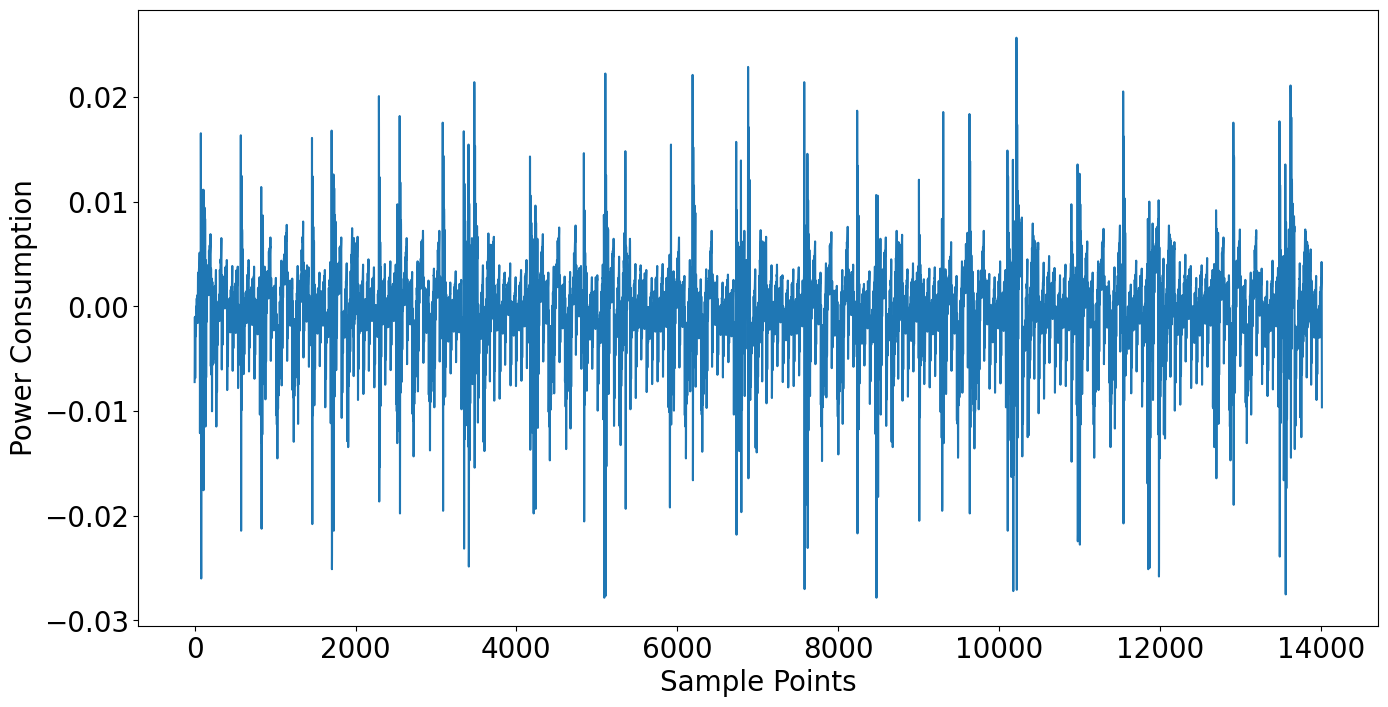

In [25]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(processed_signals[1])
plt.savefig(f'figure/trace_preprocess_split/{platform}_{opt}_single_byte.png', dpi=200, bbox_inches='tight')

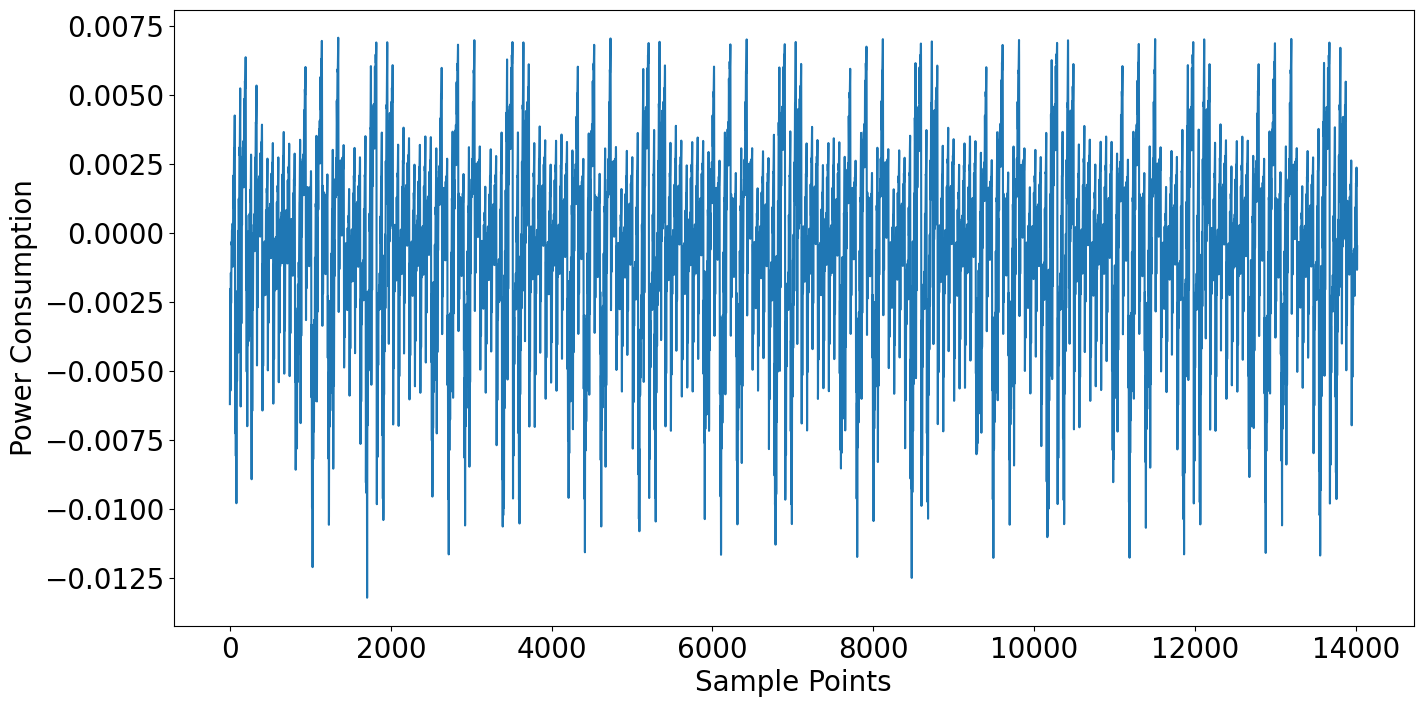

In [26]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(np.mean(processed_signals, axis=0))
plt.savefig(f'figure/trace_preprocess_split/{platform}_{opt}_mean_byte.png', dpi=200, bbox_inches='tight')


In [27]:
print(processed_signals.shape)
print(processed_labels.shape)

(64000, 14016)
(64000,)


#### 儲存合併後的trace

In [28]:
# poi = '_segment' # _poi or _segment
# oscilloscope = "picoscope" # chipwhisperer or picoscope
# trace_path = f'traces_train/{trace_num}/traces_unfixed_message_{trace_num}_{oscilloscope}_{platform}_{opt}_{algo}{poi}_{order}'

# if not os.path.exists(trace_path):
#     os.makedirs(trace_path)
#     print(f"已創建目錄: {trace_path}")


# np.save(f'{trace_path}/trace.npy', processed_signals)
# np.save(f'{trace_path}/label.npy', processed_labels)
# print('done')

In [29]:
print(l)

[[116. 224.  11. ...   5. 141.  26.]
 [252.   7. 243. ...  58.  26.  43.]
 [ 22.  73.   3. ... 166.  16. 124.]
 ...
 [101.  94. 126. ... 250.  70.  99.]
 [  4.  99. 150. ... 140. 211. 153.]
 [211. 254. 103. ...  72. 192.  66.]]


In [30]:
print(processed_labels[1])

224.0
